# Risk Analyst Case

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## "2.1 Get Your Hands Dirty" Section

### 1.Analyze the provided data

In [2]:
df = pd.read_csv("transactional-sample.csv")

In [3]:
df.head()

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      3199 non-null   int64  
 1   merchant_id         3199 non-null   int64  
 2   user_id             3199 non-null   int64  
 3   card_number         3199 non-null   str    
 4   transaction_date    3199 non-null   str    
 5   transaction_amount  3199 non-null   float64
 6   device_id           2369 non-null   float64
 7   has_cbk             3199 non-null   bool   
dtypes: bool(1), float64(2), int64(3), str(2)
memory usage: 178.2 KB


The dataset contains 3,199 transactions with no missing values in critical transactional fields. However, approximately 26% of the records have missing device identifiers, which may represent either data collection limitations or potentially suspicious behavior.

#### device_id

In [5]:
df.groupby(df['device_id'].isnull())['has_cbk'].mean()

device_id
False    0.136767
True     0.080723
Name: has_cbk, dtype: float64

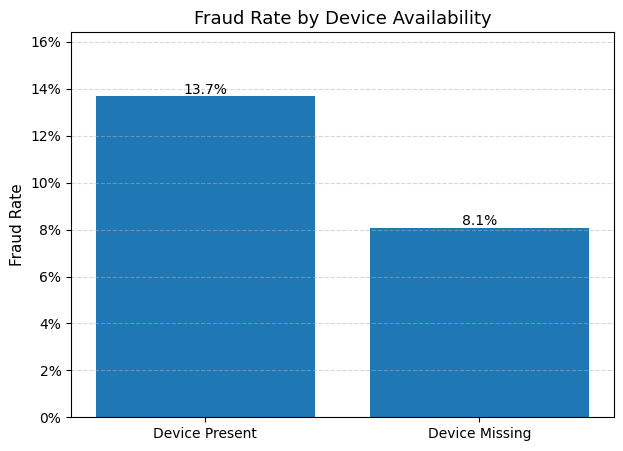

In [6]:
data = df.groupby(df['device_id'].isnull())['has_cbk'].mean()
data.index = ['Device Present', 'Device Missing']

plt.figure(figsize=(7,5))

bars = plt.bar(data.index, data.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1%}',
        ha='center',
        va='bottom'
    )

plt.title("Fraud Rate by Device Availability", fontsize=13)
plt.ylabel("Fraud Rate", fontsize=11)

plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')

plt.ylim(0, max(data.values) * 1.2)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=0)

plt.show()

Transactions with identified devices showed a higher chargeback rate (13.7%) compared to those without device information (8.1%). This suggests that fraudsters may be operating through consistent or reusable devices, rather than attempting to hide device identity.

Since most chargeback cases are contained within the portion that includes device identification, and since this makes device identification tangible, the unidentified portion will be filtered from this study at this time.

In [7]:
df_device = df.groupby('device_id')['has_cbk'].agg(['count', 'mean']).sort_values('mean', ascending=False)
df_device.head(10)

,count,mean
device_id,,
6638.0,1,1.0
287404.0,1,1.0
306719.0,2,1.0
307489.0,2,1.0
486.0,4,1.0
69227.0,2,1.0
367746.0,1,1.0
122092.0,4,1.0
180611.0,3,1.0


In [10]:
df_device_dist = (
    df_device['mean']
    .value_counts()
    .rename_axis('fraud_rate')   
    .reset_index(name='device_count')
    .sort_values(by='fraud_rate', ascending=False)
)

df_device_dist['fraud_rate'] = (df_device_dist['fraud_rate'] * 100).round(2)

df_device_dist

,fraud_rate,device_count
1,100.00,102
7,92.86,1
8,92.31,1
9,88.24,1
10,86.36,1
11,85.71,1
4,80.00,3
12,78.95,1
13,75.00,1
3,66.67,5


In [11]:
def categorize_rate(x):
    if x == 0:
        return '0% (No Fraud)'
    elif x < 0.5:
        return 'Low (<50%)'
    elif x < 1:
        return 'Medium (50-99%)'
    else:
        return '100% (All Fraud)'

df_device['fraud_category'] = df_device['mean'].apply(categorize_rate)

summary = df_device['fraud_category'].value_counts().reset_index()
summary.columns = ['fraud_category', 'device_count']

summary

,fraud_category,device_count
0,0% (No Fraud),1867
1,100% (All Fraud),102
2,Medium (50-99%),22
3,Low (<50%),5


The distribution of chargeback rates across devices shows that most devices have no associated fraud, while a smaller subset exhibits extremely high fraud rates, including a significant number of devices with 100% chargeback incidence.

There are devices that show multiple transactions with a 100% fraud rate; however, there are also devices with only one transaction that resulted in a chargeback. Therefore, to reduce the risk of false positives, a new filter will be applied to check for devices with multiple chargebacked transactions.

In [12]:
df_device_filtered = df_device[df_device['count'] >= 3].sort_values('mean', ascending=False)

df_device_filtered.head(10)

,count,mean,fraud_rate,fraud_category
device_id,,,,
486.0,4,1.0,1.0,100% (All Fraud)
122092.0,4,1.0,1.0,100% (All Fraud)
180611.0,3,1.0,1.0,100% (All Fraud)
308950.0,5,1.0,1.0,100% (All Fraud)
960729.0,6,1.0,1.0,100% (All Fraud)
288714.0,4,1.0,1.0,100% (All Fraud)
81082.0,3,1.0,1.0,100% (All Fraud)
20098.0,3,1.0,1.0,100% (All Fraud)
357277.0,6,1.0,1.0,100% (All Fraud)


In [13]:
df_device_filtered['mean'].value_counts().reset_index().rename(columns={
    'index': 'fraud_rate',
    'mean': 'device_count'
})

,device_count,count
0,1.000000,26
1,0.000000,16
2,0.666667,5
3,0.800000,3
4,0.333333,2
5,0.250000,2
6,0.928571,1
7,0.923077,1
8,0.882353,1
9,0.863636,1


In [15]:
df_device_filtered_full = df_device[df_device['count'] >= 3]

df_device_dist_filtered = (
    df_device_filtered_full['mean']
    .value_counts()
    .rename_axis('fraud_rate') 
    .reset_index(name='device_count')
    .sort_values(by='fraud_rate', ascending=False)
)

df_device_dist_filtered['fraud_rate'] = (
    df_device_dist_filtered['fraud_rate'] * 100
).round(2)

df_device_dist_filtered

,fraud_rate,device_count
0,100.00,26
6,92.86,1
7,92.31,1
8,88.24,1
9,86.36,1
10,85.71,1
3,80.00,3
11,78.95,1
12,75.00,1
2,66.67,5


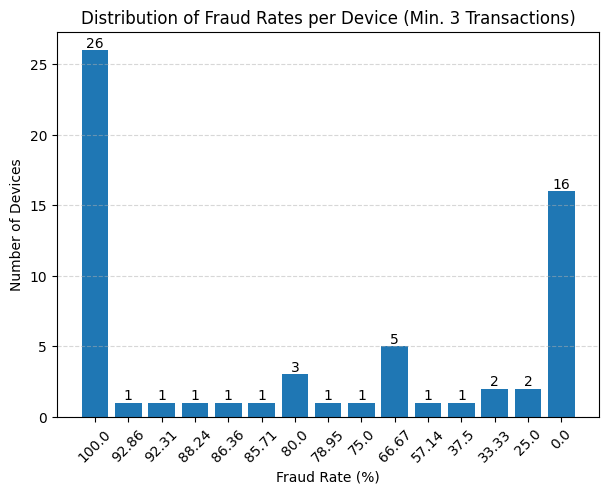

In [ ]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    df_device_dist_filtered['fraud_rate'].astype(str),
    df_device_dist_filtered['device_count']
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Fraud Rates per Device (Min. 3 Transactions)")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Number of Devices")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

After filtering devices with at least three transactions, several devices were identified with a 100% chargeback rate. This indicates consistent fraudulent behavior rather than isolated incidents, suggesting the presence of compromised or controlled devices being repeatedly used for fraudulent transactions.

##### Actions:

Devices identified with consistent fraudulent behavior should be blocked or flagged for review. Additionally, device-level monitoring and risk scoring should be implemented to prevent future fraud and improve detection accuracy.

#### User_id

In [17]:
df_user = (
    df.groupby('user_id')['has_cbk']
    .agg(['count', 'mean'])
    .rename(columns={
        'count': 'transactions',
        'mean': 'fraud_rate'
    })
)

top_users = (
    df_user
    .sort_values('transactions', ascending=False)
    .head(10)
    .copy()
)

# formatar fraude em %
top_users['fraud_rate'] = (top_users['fraud_rate'] * 100).round(2)

top_users

,transactions,fraud_rate
user_id,,
11750,31,80.65
91637,22,86.36
79054,17,88.24
96025,14,92.86
78262,13,92.31
75710,10,100.00
9853,9,44.44
56877,9,55.56
11452,8,37.50


In [18]:
top_users = (
    df_user
    .sort_values(['fraud_rate', 'transactions'], ascending=False)
    .head(10)
)

top_users['fraud_rate'] = (top_users['fraud_rate'] * 100).round(2)

top_users

,transactions,fraud_rate
user_id,,
75710,10,100.0
7725,7,100.0
17929,6,100.0
21768,6,100.0
28218,5,100.0
71424,5,100.0
86411,5,100.0
99396,5,100.0
11065,4,100.0


User-level analysis revealed the presence of users with both high transaction volumes and elevated chargeback rates. In some cases, users exhibited consistent fraudulent outcomes across multiple transactions. However, such behavior may represent either fraudulent actors or compromised accounts, requiring further analysis through device relationships.

#### User-Device Relation

In [19]:
df['device_user_count'] = df.groupby('device_id')['user_id'].transform('nunique')

summary = (
    df.groupby('device_user_count')
    .size()
    .reset_index(name='transactions')
    .rename(columns={'device_user_count': 'users_per_device'})
)

summary['percentage'] = (summary['transactions'] / summary['transactions'].sum() * 100).round(2)

summary

,users_per_device,transactions,percentage
0,1.0,2369,100.0


The analysis of device-user relationships revealed that each device in the dataset are associated with a single user (device_user_count = 1). Within this group, the observed chargeback rate is approximately 13.7%.

This lack of variability indicates that no device sharing behavior is present in the dataset, preventing the identification of fraud patterns based on multiple users per device. Therefore, fraud in this context appears to be linked to individual user-device pairs rather than shared environments.

In [20]:
df['user_device_count'] = df.groupby('user_id')['device_id'].transform('nunique')

summary = df.groupby('user_device_count')['has_cbk'].agg(['count', 'mean']).reset_index()
summary.columns = ['devices_per_user', 'transactions', 'fraud_rate']

summary

,devices_per_user,transactions,fraud_rate
0,0,811,0.073983
1,1,2266,0.116946
2,2,82,0.439024
3,3,9,0.555556
4,4,31,0.806452


In [21]:
summary = (
    df.groupby('user_device_count')['has_cbk']
    .agg(['count', 'mean'])
    .reset_index()
    .rename(columns={
        'user_device_count': 'devices_per_user',
        'count': 'transactions',
        'mean': 'fraud_rate'
    })
)

summary['fraud_rate'] = (summary['fraud_rate'] * 100).round(2)

summary = summary.sort_values('devices_per_user')

summary

,devices_per_user,transactions,fraud_rate
0,0,811,7.40
1,1,2266,11.69
2,2,82,43.90
3,3,9,55.56
4,4,31,80.65


The analysis reveals a strong positive relationship between the number of devices used per user and the likelihood of fraud. While most transactions are associated with users operating on a single device, showing a relatively low fraud rate (~11.7%), users linked to multiple devices exhibit significantly higher fraud rates, exceeding 80% for those using four devices.

Despite representing a smaller portion of total transactions, these multi-device users concentrate a disproportionately high level of fraud, indicating the presence of high-risk behavioral patterns.

This suggests that multi-device usage is a critical risk indicator, potentially associated with compromised credentials or deliberate attempts to evade detection in a card-not-present environment

##### Actions:

Users associated with multiple devices should be considered higher risk. Monitoring device usage per user and applying additional verification for such cases can help prevent fraud, especially in card-not-present transactions.

#### transaction_amount

In [22]:
df.groupby('has_cbk')['transaction_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
has_cbk,,,,,,,,
False,2808.0,672.324380,797.463853,1.22,191.285,360.315,812.5775,4091.83
True,391.0,1453.571918,1169.491346,2.89,565.580,999.470,2140.6800,4097.21


<Figure size 700x500 with 0 Axes>

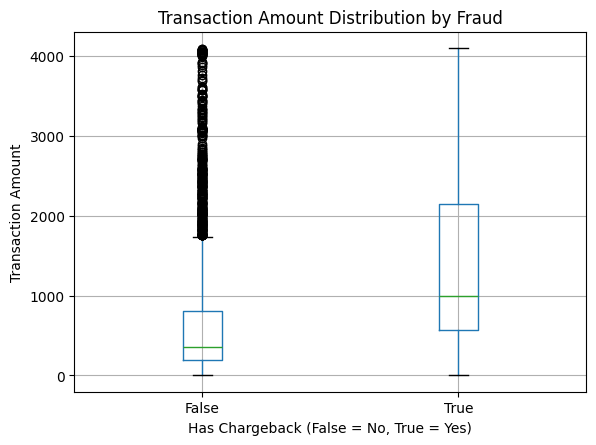

In [23]:
plt.figure(figsize=(7,5))

df.boxplot(column='transaction_amount', by='has_cbk')

plt.title("Transaction Amount Distribution by Fraud")
plt.suptitle("")  
plt.xlabel("Has Chargeback (False = No, True = Yes)")
plt.ylabel("Transaction Amount")

plt.show()

Fraudulent transactions exhibit significantly higher values compared to legitimate ones, with both average and median amounts substantially elevated. This indicates that fraud is concentrated in higher-value transactions, likely reflecting attempts to maximize financial gain.

This reinforces the importance of incorporating transaction amount as a key feature in fraud detection models, especially when combined with behavioral indicators such as multi-device usage.

#### transaction-user_device relation

In [24]:
summary = df.groupby('user_device_count')['transaction_amount'].agg(
    transactions='count',
    avg_amount='mean',
    median_amount='median'
).reset_index()

summary['avg_amount'] = summary['avg_amount'].round(2)
summary['median_amount'] = summary['median_amount'].round(2)

summary

,user_device_count,transactions,avg_amount,median_amount
0,0,811,830.54,428.29
1,1,2266,741.23,392.69
2,2,82,881.29,566.60
3,3,9,1439.24,820.01
4,4,31,574.72,607.45


The analysis does not show a clear linear relationship between the number of devices per user and transaction amount. While most user groups (0–2 devices) present relatively stable average transaction values, users associated with three devices stand out with significantly higher transaction amounts.

However, this pattern is not consistent across all segments, as users with four devices do not follow the same trend, suggesting that transaction amount alone is not a sufficient indicator of risk.

Instead, the data suggests the presence of a specific high-risk behavioral cluster combining multi-device usage and higher transaction values, rather than a general trend across all users.

#### transaction_date

In [25]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df1 = df.sort_values(['user_id', 'transaction_date'])
df1['time_diff'] = df1.groupby('user_id')['transaction_date'].diff().dt.total_seconds()
df1['time_diff'].describe()

count    4.950000e+02
mean     1.264441e+05
std      2.959686e+05
min      1.722561e+01
25%      8.041818e+02
50%      5.170820e+03
75%      8.910973e+04
max      2.218982e+06
Name: time_diff, dtype: float64

In [26]:
df1['time_diff_hours'] = df1['time_diff'] / 3600

summary = (
    df1.groupby('has_cbk')['time_diff_hours']
    .agg(['count','mean','median','max'])
    .rename(columns={
        'count': 'transactions',
        'mean': 'avg_hours',
        'median': 'median_hours',
        'max': 'max_hours'
    })
)

summary = summary.round(2)

summary

,transactions,avg_hours,median_hours,max_hours
has_cbk,,,,
False,235,56.27,7.79,616.38
True,260,16.01,0.80,402.76


Fraudulent and non-fraudulent transactions show distinct behavioral differences in transaction velocity.

Fraudulent transactions tend to have significantly shorter median time intervals between events(median≈0.8 hours), indicating burst-like activity patterns. In contrast, non-fraudulent transactions are more spread out over time(median≈7.8 hours), reflecting more regular user behavior.

#### merchant_id

In [27]:
df_merchant = df.groupby('merchant_id')['has_cbk'].agg(['count', 'mean'])
df_merchant_filtered = df_merchant[df_merchant['count'] >= 5].sort_values('mean', ascending=False)

df_merchant_filtered.head(10)

,count,mean
merchant_id,,
1308,15,1.0
8942,5,1.0
38337,6,1.0
38568,5,1.0
15326,5,1.0
81795,6,1.0
75917,6,1.0
73271,10,1.0
48126,6,1.0


Merchant-level analysis revealed the existence of specific merchants with a 100% chargeback rate across multiple transactions. Given the minimum transaction threshold applied, this pattern is unlikely to be random and strongly suggests concentrated fraudulent activity associated with particular merchants.

This indicates that fraud risk is not only driven by user or device behavior but may also be influenced by merchant-specific factors, such as the nature of the business, transaction flow, or potential exploitation by fraudsters.

#### merchat + user + device

In [28]:
df_triple = df.groupby(['user_id', 'device_id', 'merchant_id'])['has_cbk'].agg(['count', 'mean']).reset_index()

df_triple_filtered = df_triple[df_triple['count'] >= 3].sort_values('mean', ascending=False)

df_triple_filtered.head(10)

,user_id,device_id,merchant_id,count,mean
140,6761,738394.0,38755,3,1.0
159,7725,308950.0,73271,5,1.0
220,11065,698520.0,42356,4,1.0
445,21768,357277.0,44927,4,1.0
374,17929,960729.0,75917,4,1.0
788,40493,760682.0,38337,3,1.0
1033,53850,20098.0,55854,3,1.0
562,28218,174844.0,53041,5,1.0
630,31819,790235.0,52897,3,1.0
982,50643,570971.0,29214,4,1.0


In [29]:
df_triple[(df_triple["mean"] == 1) & (df_triple["count"] > 2)].shape

(27, 5)

The combined analysis of user, device, and merchant relationships reveals repeated patterns of fraudulent transactions occurring within the same entity combinations. Several cases show multiple transactions involving the same user, device, and merchant, all resulting in chargebacks.

This consistent behavior strongly suggests coordinated or systematic fraud, rather than isolated incidents. The recurrence of these patterns indicates that specific combinations of users, devices, and merchants are being exploited repeatedly, potentially representing controlled environments or organized fraud activity.

#### Correlation

In [30]:
cols = [
    'transaction_amount',
    'time_diff_hours',
    'user_device_count',
]

corr_matrix = df1[cols].corr()
corr_matrix

,transaction_amount,time_diff_hours,user_device_count
transaction_amount,1.000000,-0.023373,-0.028596
time_diff_hours,-0.023373,1.000000,-0.052175
user_device_count,-0.028596,-0.052175,1.000000


In [31]:
corr_matrix.rename(index={
    'transaction_amount': 'Amount',
    'time_diff_hours': 'Time (Hours)',
    'user_device_count': 'Devices per User'
}, columns={
    'transaction_amount': 'Amount',
    'time_diff_hours': 'Time (Hours)',
    'user_device_count': 'Devices per User'
}, inplace=True)

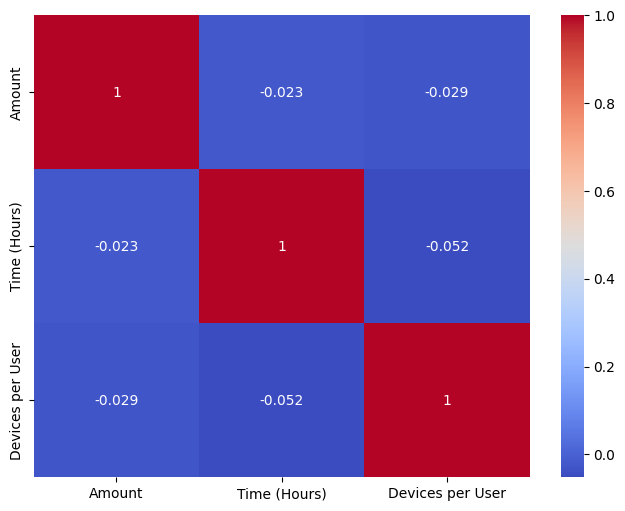

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Correlation analysis shows that fraud-related variables such as transaction amount, time intervals, and user-device behavior exhibit very weak linear relationships. This indicates that fraudulent behavior is not driven by any single dominant factor.

Instead, fraud appears to emerge from the interaction of multiple weak signals, reinforcing the need for multivariate models or rule-based systems that combine behavioral, financial, and temporal features.

#### interactions

Fraudulent activity is rarely driven by a single factor; instead, it typically emerges from the interaction of multiple signals, such as transaction characteristics, user behavior, and temporal patterns.

Therefore, to better capture these non-linear relationships, an interaction-based analysis will be conducted, combining key variables to identify patterns that may not be visible when analyzed in isolation.

This approach allows for a more realistic representation of fraud behavior, aligning the analysis with how risk is assessed in real-world fraud detection systems.

In [34]:
df1['amount_bin'] = pd.qcut(df1['transaction_amount'], q=4)

df1.groupby(['amount_bin', 'user_device_count'])['has_cbk'].mean().unstack()

user_device_count,0,1,2,3,4
amount_bin,,,,,
"(1.219, 205.235]",0.015306,0.029260,0.181818,NaN,0.000000
"(205.235, 415.94]",0.030457,0.035533,0.200000,0.00,1.000000
"(415.94, 981.68]",0.071066,0.145221,0.600000,0.50,0.827586
"(981.68, 4097.21]",0.167421,0.269091,0.600000,0.75,NaN


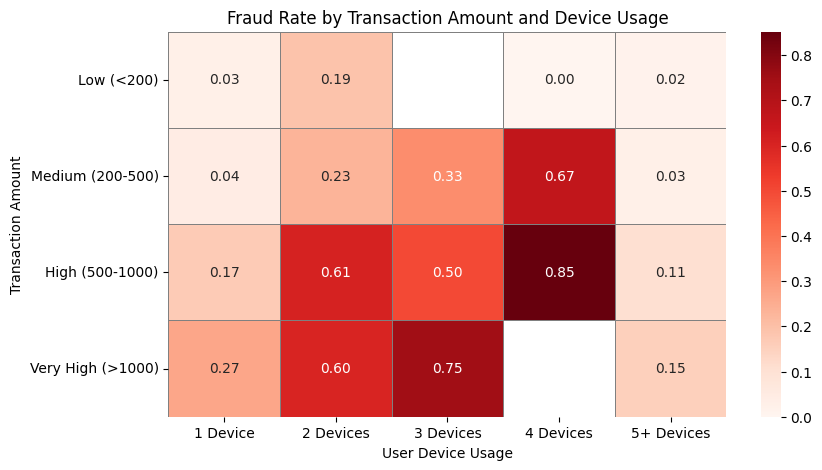

In [35]:
bins = [0, 200, 500, 1000, 5000]
labels_amount = ['Low (<200)', 'Medium (200-500)', 'High (500-1000)', 'Very High (>1000)']

df1['amount_bin'] = pd.cut(df1['transaction_amount'], bins=bins, labels=labels_amount)

def device_group(x):
    if x == 1:
        return '1 Device'
    elif x == 2:
        return '2 Devices'
    elif x == 3:
        return '3 Devices'
    elif x == 4:
        return '4 Devices'
    else:
        return '5+ Devices'
        

df1['user_device_group'] = df1['user_device_count'].apply(device_group)

pivot = df1.groupby(['amount_bin', 'user_device_group'])['has_cbk'].mean().unstack()

plt.figure(figsize=(9,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Fraud Rate by Transaction Amount and Device Usage", fontsize=12)
plt.xlabel("User Device Usage", fontsize=10)
plt.ylabel("Transaction Amount", fontsize=10)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

The interaction between transaction amount and user-device behavior reveals a strong non-linear fraud pattern. While both variables individually show moderate risk signals, their combination significantly amplifies fraud probability.

Low-value transactions present relatively low fraud rates across all user segments. However, as transaction amounts increase, users associated with multiple devices exhibit a sharp rise in fraud rates, reaching levels above 60–80% in higher-value segments.

This demonstrates that fraud risk is not driven by isolated variables, but rather by the interaction between financial and behavioral signals.

In [51]:
df1['time_bin'] = pd.qcut(df1['time_diff_hours'], q=4)

df1.groupby(['time_bin', 'amount_bin'])['has_cbk'].mean().unstack()

amount_bin,Low (<200),Medium (200-500),High (500-1000),Very High (>1000)
time_bin,,,,
"(0.0037800000000000004, 0.223]",0.238095,0.576923,0.583333,0.780488
"(0.223, 1.436]",0.200000,0.562500,0.808511,0.725490
"(1.436, 24.753]",0.136364,0.466667,0.658537,0.622222
"(24.753, 616.384]",0.040000,0.081081,0.500000,0.525000


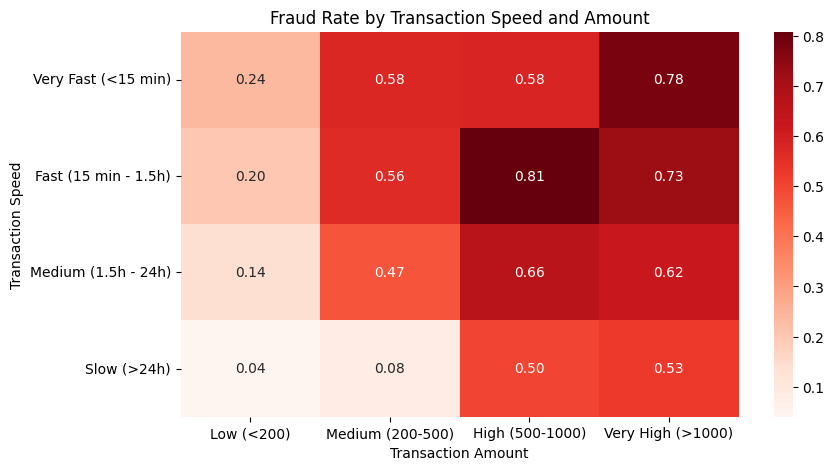

In [52]:
labels_time = [
    'Very Fast (<15 min)',
    'Fast (15 min - 1.5h)',
    'Medium (1.5h - 24h)',
    'Slow (>24h)'
]

df1['amount_bin'] = pd.cut(df1['transaction_amount'], bins=bins, labels=labels_amount)

df1['time_bin'] = pd.qcut(df1['time_diff_hours'], q=4, labels=labels_time)

pivot = df1.groupby(['time_bin', 'amount_bin'])['has_cbk'].mean().unstack()

plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")

plt.title("Fraud Rate by Transaction Speed and Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Speed")

plt.show()

The interaction analysis reveals two distinct but complementary fraud patterns. While fraud rates are significantly higher for transactions occurring within short time intervals, high-value transactions remain consistently risky even as the time between transactions increases.

This indicates that transaction amount is a strong independent risk factor, whereas transaction velocity acts as an amplifying signal. When both factors occur together, fraud risk reaches its highest levels; however, even in isolation, high-value transactions maintain elevated fraud rates.

This pattern suggests that fraudsters prioritize higher-value transactions regardless of timing, while rapid transaction sequences further increase the likelihood of fraudulent behavior.

In [ ]:
pivot = df1.groupby(['time_bin', 'user_device_count'])['has_cbk'].mean().unstack()

pivot

user_device_count,0,1,2,3,4
time_bin,,,,,
Very Fast (<15 min),0.586207,0.560976,0.727273,NaN,1.000000
Fast (15 min - 1.5h),0.461538,0.689655,0.777778,1.000000,0.846154
Medium (1.5h - 24h),0.333333,0.513514,0.600000,0.666667,0.769231
Slow (>24h),0.066667,0.341772,0.269231,0.000000,0.500000


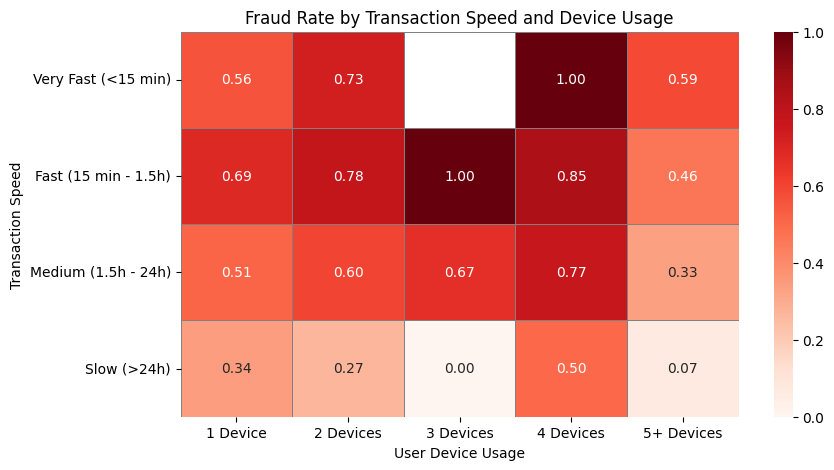

In [54]:
pivot = df1.groupby(['time_bin', 'user_device_group'])['has_cbk'].mean().unstack()

plt.figure(figsize=(9,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Fraud Rate by Transaction Speed and Device Usage")
plt.xlabel("User Device Usage")
plt.ylabel("Transaction Speed")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

The analysis of transaction velocity and device usage reveals that fraud risk is strongly influenced by both factors, with transaction speed acting as the primary driver and multi-device usage as a risk amplifier.

Fraud rates are consistently higher for transactions occurring within shorter time intervals, reaching peak levels in the “Very Fast” and “Fast” categories. While users operating across multiple devices generally exhibit higher fraud rates, especially in high-velocity scenarios, their impact is secondary compared to transaction speed.

As the time between transactions increases, fraud rates decrease significantly across all device groups, reinforcing that transaction velocity is the dominant factor in fraud behavior. Multi-device usage further amplifies this risk, although its effect may vary depending on data distribution

#### Final Recomendations (Actions)

Based on the analysis, fraud cannot be identified through a single variable but rather through the interaction of behavioral, financial, and temporal signals.

The following actions are recommended:

1. Risk-based scoring system:
Implement a fraud score combining device usage, transaction amount, and velocity patterns.

2. Step-up verification:
Apply additional authentication for users exhibiting multi-device behavior combined with high-value or rapid transactions.

3. Device-level monitoring:
Continuously monitor devices associated with high chargeback rates for potential blocking or manual review.

4. Behavioral anomaly detection:
Incorporate velocity-based signals to detect burst-like transaction patterns typical of automated fraud.

5. Real-time transaction monitoring:
Evaluate transactions at the moment they occur using the defined risk signals, enabling immediate actions such as blocking, alerting, or requesting additional verification.

6. Feedback loop and model improvement:
Continuously update risk rules and models using confirmed fraud outcomes (chargebacks) to adapt to evolving fraud patterns.

### Broaden your analysis

As indicated by the low correlation between variables in the dataset, an effective fraud detection system must rely on a broader ecosystem of data sources to achieve greater robustness and accuracy. Fraud behavior is typically multi-dimensional and cannot be reliably detected using isolated transactional signals.

Therefore, additional data that could significantly enhance fraud detection includes:

KYC and identity verification data, such as onboarding information and verification levels;
Behavioral history, including user activity patterns, spending behavior, and historical chargebacks;
Account relationship data, to identify linked or potentially synthetic identities;
Device and network intelligence, such as IP address, geolocation, device fingerprinting, and VPN/proxy/TOR usage;
Account metadata, including account age and tenure;
Transaction behavior patterns, such as purchase frequency, spending variability, and anomalies over time.

Together, these data sources enable a more holistic view of user behavior, significantly improving the ability to detect complex and evolving fraud patterns

### Provide recommendations

Based on the findings, fraud and chargeback prevention should rely on a multi-layered risk-based approach rather than isolated rules.

1. Risk-based scoring system:
Implement a dynamic risk engine that combines behavioral, financial, and temporal signals to classify transactions into risk tiers (low, medium, high).

2. Step-up authentication:
Apply additional verification mechanisms for high-risk transactions, particularly those involving multi-device usage, high transaction values, or burst-like activity patterns.

3. Device-level monitoring:
Continuously track device behavior to identify abnormal chargeback rates or multiple user associations, enabling proactive investigation or restriction.

4. Velocity-based controls:
Monitor transaction timing patterns to detect unusually fast sequences of transactions that may indicate automated or coordinated fraud attempts.

5. Manual review strategy:
Route borderline high-risk transactions to manual review to reduce false positives and improve decision accuracy.

Together, these measures create a balanced fraud prevention strategy that minimizes chargebacks while preserving user experience

### Design an anti-fraud solution

The proposed anti-fraud system is designed as a real-time, multi-layered risk detection framework that combines behavioral, transactional, and device-level data to assess fraud risk in card-not-present environments.

The architecture consists of four main components:

1. Data ingestion layer:
Collects real-time transaction data along with user, device, and network signals such as IP address and geolocation.

2. Feature engineering layer:
Transforms raw data into risk indicators, including user-device relationships, transaction velocity, and spending behavior patterns.

3. Risk scoring engine:
Aggregates all features into a unified fraud risk score using either rule-based logic or machine learning models.

4. Decision engine:
Applies business rules based on risk score, categorizing transactions into approve, step-up authentication, or decline actions.

Additionally, the system includes a feedback loop where confirmed fraud cases (chargebacks) are used to continuously refine detection models and update risk profiles.

This design ensures a scalable, adaptive, and real-time fraud prevention system capable of detecting complex and evolving fraud patterns while minimizing friction for legitimate users.